# TP 1:  Erwan Ouabdesselam

In [93]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import functools as ft
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from PIL import Image
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score,recall_score,f1_score

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
from pylab import rcParams
import matplotlib.pyplot as plt



In [125]:
def plot_confusion(prediction, target):
    '''
    plot correlation's matrix to explore dependency between features
    '''
    # list_labels_cat = ['ARTEFACTS', 'BLASTES', 'ERYTHROBLASTES', 'LYMPHOCYTES', 'MONOCYTES', 'MYELOCYTES', 'NEUTROPHILES']
    list_labels_cat = ['ARTEFACTS', 'BASOPHILES', 'BLASTES', 'EOSINOPHILES',
       'ERYTHROBLASTES', 'LYMPHOCYTES', 'METAMYELOCYTES', 'MONOCYTES',
       'MYELOCYTES', 'NEUTROPHILES', 'PROMYELOCYTES']
    # init figure size
    # targ_valids_cat = [list_labels_cat[i] for i in target]
    # preds_valids_cat = [list_labels_cat[i] for i in prediction]
    rcParams['figure.figsize'] = 7, 7
    df = pd.DataFrame(confusion_matrix(target, prediction, labels = list_labels_cat, normalize = 'true'), index = list_labels_cat, columns= list_labels_cat)
    # df = pd.DataFrame(confusion_matrix(targ_valids_cat, preds_valids_cat, labels = list_labels_cat, normalize = 'true'))

    fig = plt.figure()
    sns.heatmap(df, annot=True, fmt=".2f")
    plt.show()
    fig.savefig('corr.png')


# Import features

In [126]:
features_table = pd.read_csv('features_table_renamed_features.csv')
len(features_table.columns)

42

In [127]:
features_table.head()

,Unnamed: 0,cytoID,Hematoxylin_Mean_nuclei,Hematoxylin_Std_dev_nuclei,Hematoxylin_Min_nuclei,Hematoxylin_Max_nuclei,Hematoxylin_Median_nuclei,Eosin_Mean_nuclei,Eosin_Std_dev_nuclei,Eosin_Min_nuclei,...,Eosin_Min_cytoonly,Eosin_Max_cytoonly,Hue_Mean_cytoonly,Saturation_Mean_cytoonly,Saturation_Std_dev_cytoonly,Saturation_Min_cytoonly,Saturation_Max_cytoonly,Saturation_Median_cytoonly,Eosin_Median_cytoonly,Area_µm^2_cytoonly
0,0,837,0.3095,0.0945,0.0600,0.6984,0.3025,0.2581,0.1013,0.0578,...,-0.0108,0.9250,0.2995,0.0803,0.1068,0.0,0.9489,0.0335,0.0275,580.8835
1,1,447,0.3790,0.1280,0.0738,0.8538,0.3595,0.3362,0.2064,0.0346,...,0.0053,1.5916,0.3480,0.2224,0.0871,0.0,1.0000,0.2375,0.1405,336.1428
2,2,435,0.4304,0.1727,0.0384,1.0462,0.4145,0.4348,0.3306,0.0145,...,-0.0075,1.6237,0.3540,0.2508,0.0988,0.0,1.0000,0.2455,0.1545,295.5429
3,3,737,0.3011,0.1867,0.0271,1.3582,0.2535,0.2454,0.2487,-0.0462,...,-0.0287,1.6220,0.3327,0.3251,0.1391,0.0,1.0000,0.2905,0.1805,176.0093
4,4,176,0.3344,0.1360,0.0294,0.8590,0.3345,0.3085,0.1938,0.0077,...,-0.0013,0.6878,0.3425,0.2027,0.0729,0.0,0.8716,0.2135,0.0965,264.4129


# Find null values

1) List the number of null values for each column. Which column has nan values?


2) Delete the rows where there are nan values


In [128]:
#Answer q1+q2
null_columns = []
non_null_columns = []
for col in features_table.columns:
    if features_table[col].isnull().sum()==0:
        non_null_columns.append(col)
    if features_table[col].isnull().sum()!=0:
        null_columns.append(col)

print("les colonnes suivantes n'ont aucune valeur null",non_null_columns)
print("les colonnes suivantes ont des valeurs null",null_columns)

features_table=features_table.dropna()

les colonnes suivantes n'ont aucune valeur null ['Unnamed: 0', 'cytoID', 'Hematoxylin_Mean_nuclei', 'Hematoxylin_Std_dev_nuclei', 'Hematoxylin_Min_nuclei', 'Hematoxylin_Max_nuclei', 'Hematoxylin_Median_nuclei', 'Eosin_Mean_nuclei', 'Eosin_Std_dev_nuclei', 'Eosin_Min_nuclei', 'Eosin_Max_nuclei', 'Hue_Mean_nuclei', 'Saturation_Mean_nuclei', 'Saturation_Std_dev_nuclei', 'Saturation_Min_nuclei', 'Saturation_Max_nuclei', 'Saturation_Median_nuclei', 'Eosin_Median_nuclei', 'Area_µm^2_nuclei', 'Length_µm_cyto', 'Solidity_cyto', 'Max_diameter_µm_cyto', 'Min_diameter_µm_cyto', 'Perimeter_µm_cyto', 'Hematoxylin_Mean_cytoonly', 'Hematoxylin_Std_dev_cytoonly', 'Hematoxylin_Min_cytoonly', 'Hematoxylin_Max_cytoonly', 'Hematoxylin_Median_cytoonly', 'Eosin_Mean_cytoonly', 'Eosin_Std_dev_cytoonly', 'Eosin_Min_cytoonly', 'Eosin_Max_cytoonly', 'Hue_Mean_cytoonly', 'Saturation_Mean_cytoonly', 'Saturation_Std_dev_cytoonly', 'Saturation_Min_cytoonly', 'Saturation_Max_cytoonly', 'Saturation_Median_cytoonly', 

# Add labels

In [129]:
labels = pd.read_csv('labels.csv')
labels

,Unnamed: 0,cytoID,label
0,0,628,NEUTROPHILES
1,1,468,NEUTROPHILES
2,2,55,NEUTROPHILES
3,3,464,NEUTROPHILES
4,4,541,BLASTES
...,...,...,...
3135,2012,2561,LYMPHOCYTES
3136,2013,2829,ERYTHROBLASTES
3137,2014,2591,NEUTROPHILES
3138,2015,2849,ERYTHROBLASTES


3) We want to remove the labels of the cells deleted in the previous question. To do so, create a new dataframe "*dataset*" generated by the joint of *features_table* and *labels* on **cytoID** number.

In [130]:
dataset = features_table.merge(labels, left_on= 'cytoID', right_on= 'cytoID')

In [131]:
dataset = dataset.dropna()

# Visualise the distribution of the class



4) Count the number of cells per class. What can we say about the distribution of the classes?

5) Plot the distribution of the classes using sns.countplot() and the dataframe.

*Expected result*

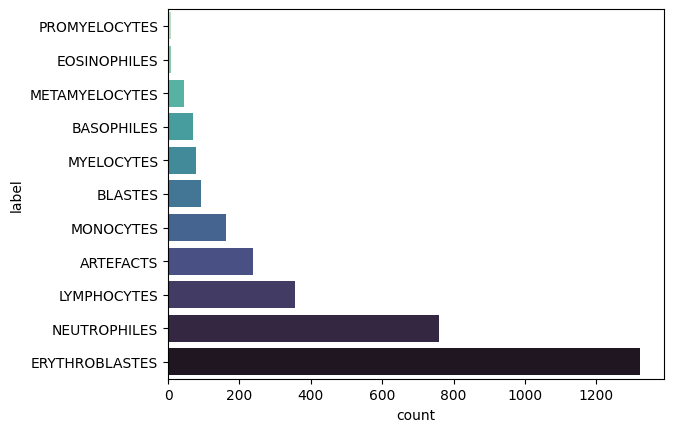

Il y'a 749 cellules pour la class NEUTROPHILES
Il y'a 44 cellules pour la class METAMYELOCYTES
Il y'a 357 cellules pour la class LYMPHOCYTES
Il y'a 91 cellules pour la class BLASTES
Il y'a 77 cellules pour la class MYELOCYTES
Il y'a 231 cellules pour la class ARTEFACTS
Il y'a 6 cellules pour la class PROMYELOCYTES
Il y'a 68 cellules pour la class BASOPHILES
Il y'a 7 cellules pour la class EOSINOPHILES
Il y'a 1320 cellules pour la class ERYTHROBLASTES
Il y'a 160 cellules pour la class MONOCYTES


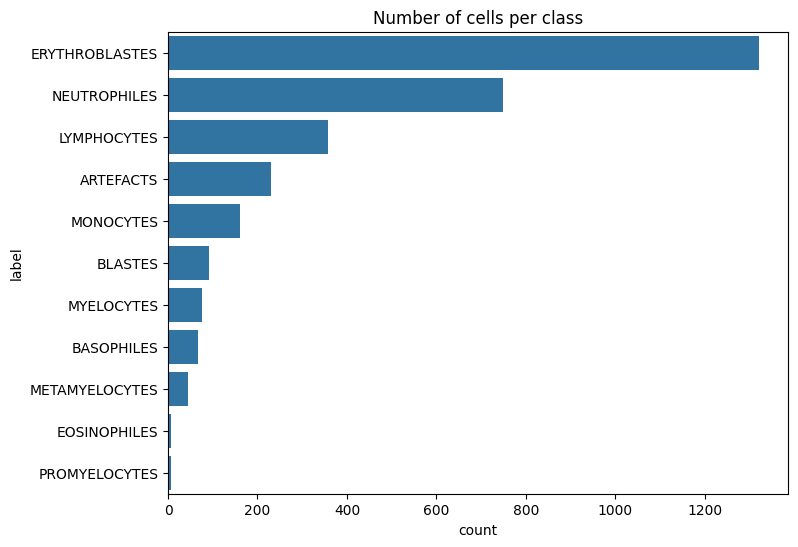

In [132]:
# Answer q4 + q5
list_labels=dataset["label"].unique()
count_per_label=[]
for label in list_labels:
    count=len(dataset[dataset["label"]==label])
    count_per_label.append(count)
    print("Il y'a", count, "cellules pour la class",label)


plt.figure(figsize=(8,6))
sns.countplot(
    y="label",          # axe vertical
    data=dataset,
    order=dataset["label"].value_counts().index  # pour trier par fréquence
)

plt.xlabel("count")
plt.ylabel("label")
plt.title("Number of cells per class")
plt.show()

# Visualise features

We can use .describe() to visualise the behaviour of each feature.

In [133]:
dataset.describe()

,Unnamed: 0_x,cytoID,Hematoxylin_Mean_nuclei,Hematoxylin_Std_dev_nuclei,Hematoxylin_Min_nuclei,Hematoxylin_Max_nuclei,Hematoxylin_Median_nuclei,Eosin_Mean_nuclei,Eosin_Std_dev_nuclei,Eosin_Min_nuclei,...,Eosin_Max_cytoonly,Hue_Mean_cytoonly,Saturation_Mean_cytoonly,Saturation_Std_dev_cytoonly,Saturation_Min_cytoonly,Saturation_Max_cytoonly,Saturation_Median_cytoonly,Eosin_Median_cytoonly,Area_µm^2_cytoonly,Unnamed: 0_y
count,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,...,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000
mean,850.220900,1574.875241,0.863911,0.242266,0.151510,1.767968,0.864445,0.226423,0.237001,-0.271824,...,0.975739,0.241823,0.258577,0.148072,0.022247,0.895672,0.227580,0.044030,51.556067,847.837299
std,548.072579,906.189013,0.641885,0.162756,0.139328,1.195020,0.647994,0.166961,0.120402,0.459606,...,0.522370,0.059630,0.101322,0.063019,0.033845,0.168434,0.095092,0.046182,55.102101,549.702719
min,0.000000,1.000000,0.136200,0.033600,-0.049300,0.276500,0.073500,-0.734400,0.011200,-1.943500,...,-0.026800,0.131100,0.044500,0.029800,0.000000,0.233300,0.021500,0.000000,0.511500,0.000000
25%,394.250000,790.250000,0.354775,0.117500,0.047750,0.861900,0.344500,0.122150,0.131950,-0.261100,...,0.454475,0.189450,0.189400,0.098900,0.000000,0.841075,0.165750,0.000000,12.195700,391.000000
50%,787.000000,1577.500000,0.577000,0.186700,0.105150,1.273900,0.559500,0.221650,0.239900,-0.083050,...,1.119400,0.239900,0.237550,0.134550,0.008500,1.000000,0.212500,0.033500,26.240350,783.500000
75%,1233.750000,2358.750000,1.258450,0.324700,0.218575,2.319775,1.299250,0.315475,0.332725,0.002475,...,1.395700,0.297050,0.311675,0.188175,0.028450,1.000000,0.273500,0.075500,79.882625,1234.750000
max,2015.000000,3140.000000,3.193700,0.996000,1.147000,4.278200,3.139500,0.911500,0.684200,0.179200,...,3.855600,0.477700,0.791600,0.367300,0.328700,1.000000,0.962500,0.692500,580.883500,2016.000000


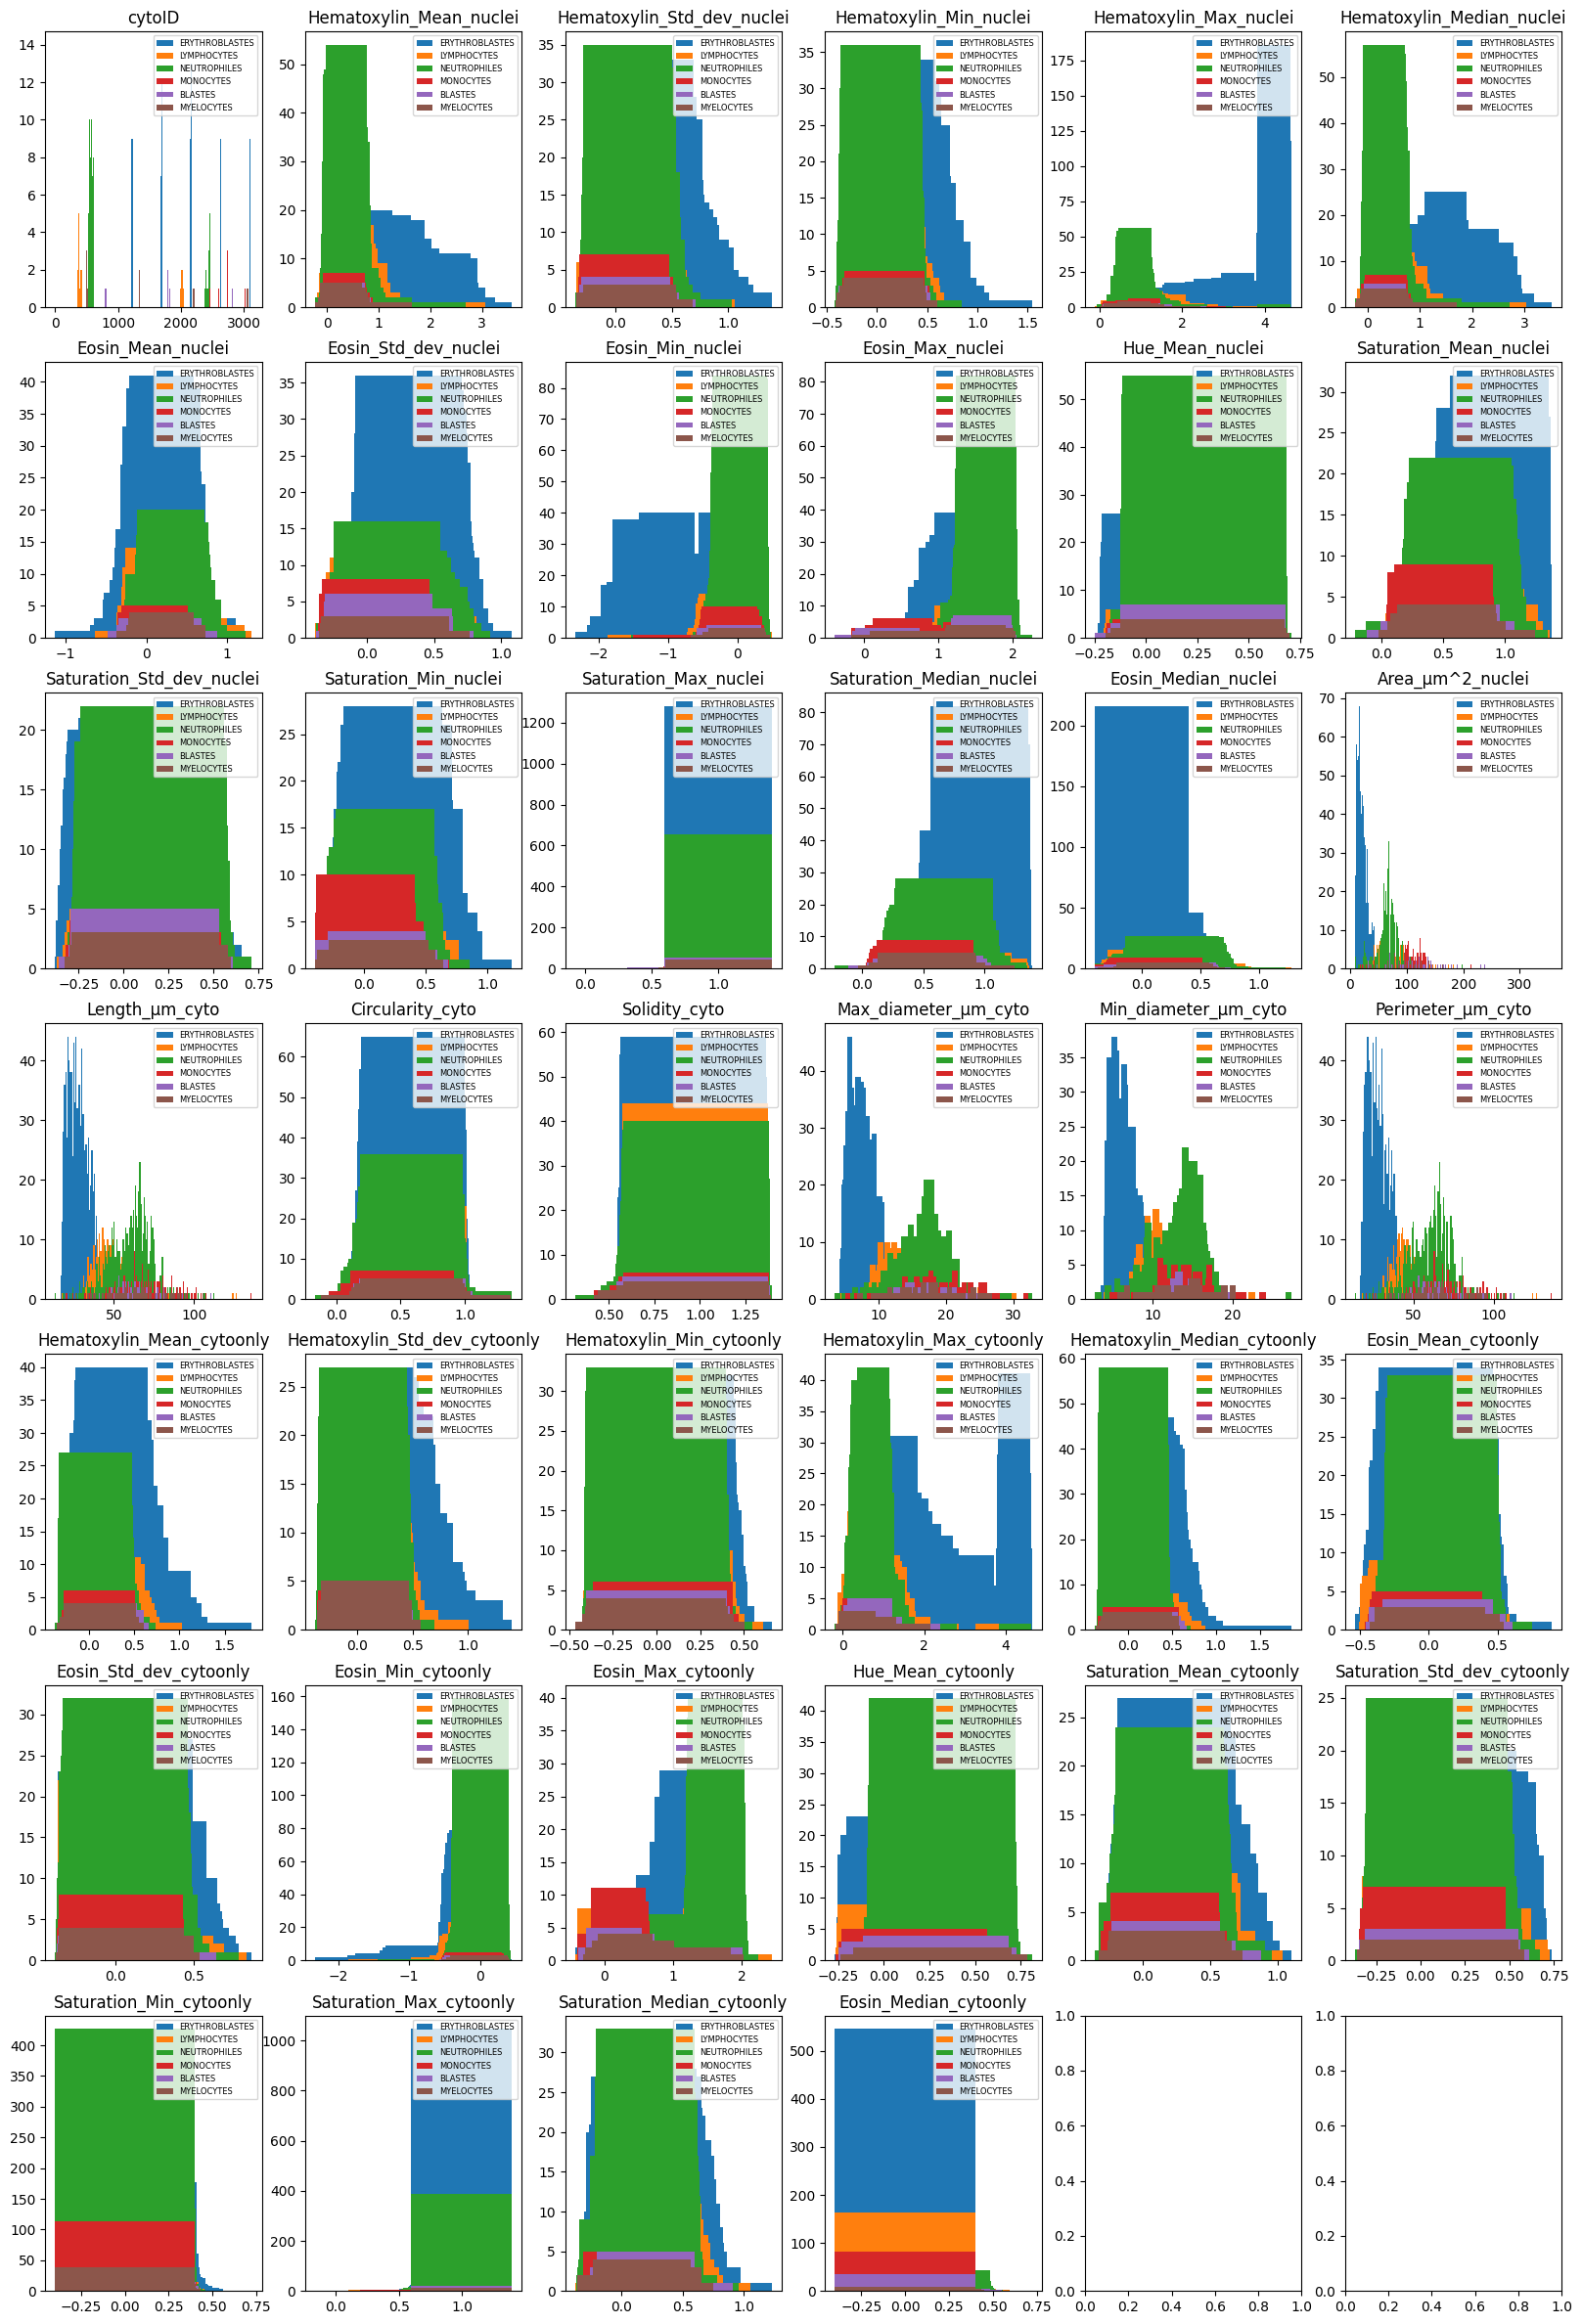

In [134]:
rcParams['figure.figsize'] = 20, 30
fig, axes = plt.subplots(7,6)

for i, ax in enumerate(axes.flat, start=1):
    if i < 41:
        y_max = 0
        for k in ['ERYTHROBLASTES', 'LYMPHOCYTES','NEUTROPHILES', 'MONOCYTES',  'BLASTES', 'MYELOCYTES']:

            sub_df = dataset.loc[dataset.label == k]

            sub_df =sub_df.drop('label', axis = 1)
            a_heights, a_bins = np.histogram(np.array(sub_df[dataset.columns[i]], dtype=float), bins=200)
            if max(a_heights) + max(a_heights)*0.05 > y_max:
                y_max = max(a_heights) + max(a_heights)*0.05

            ax.bar(a_bins[:-1], a_heights, label = k)
            ax.legend(loc="upper right", prop={'size': 6})
            ax.set_ylim((0, y_max))
            ax.set_xlabel = ('Feature value')
            ax.set_ylabel = ('Number of cells')
            ax.set_title(dataset.columns[i])


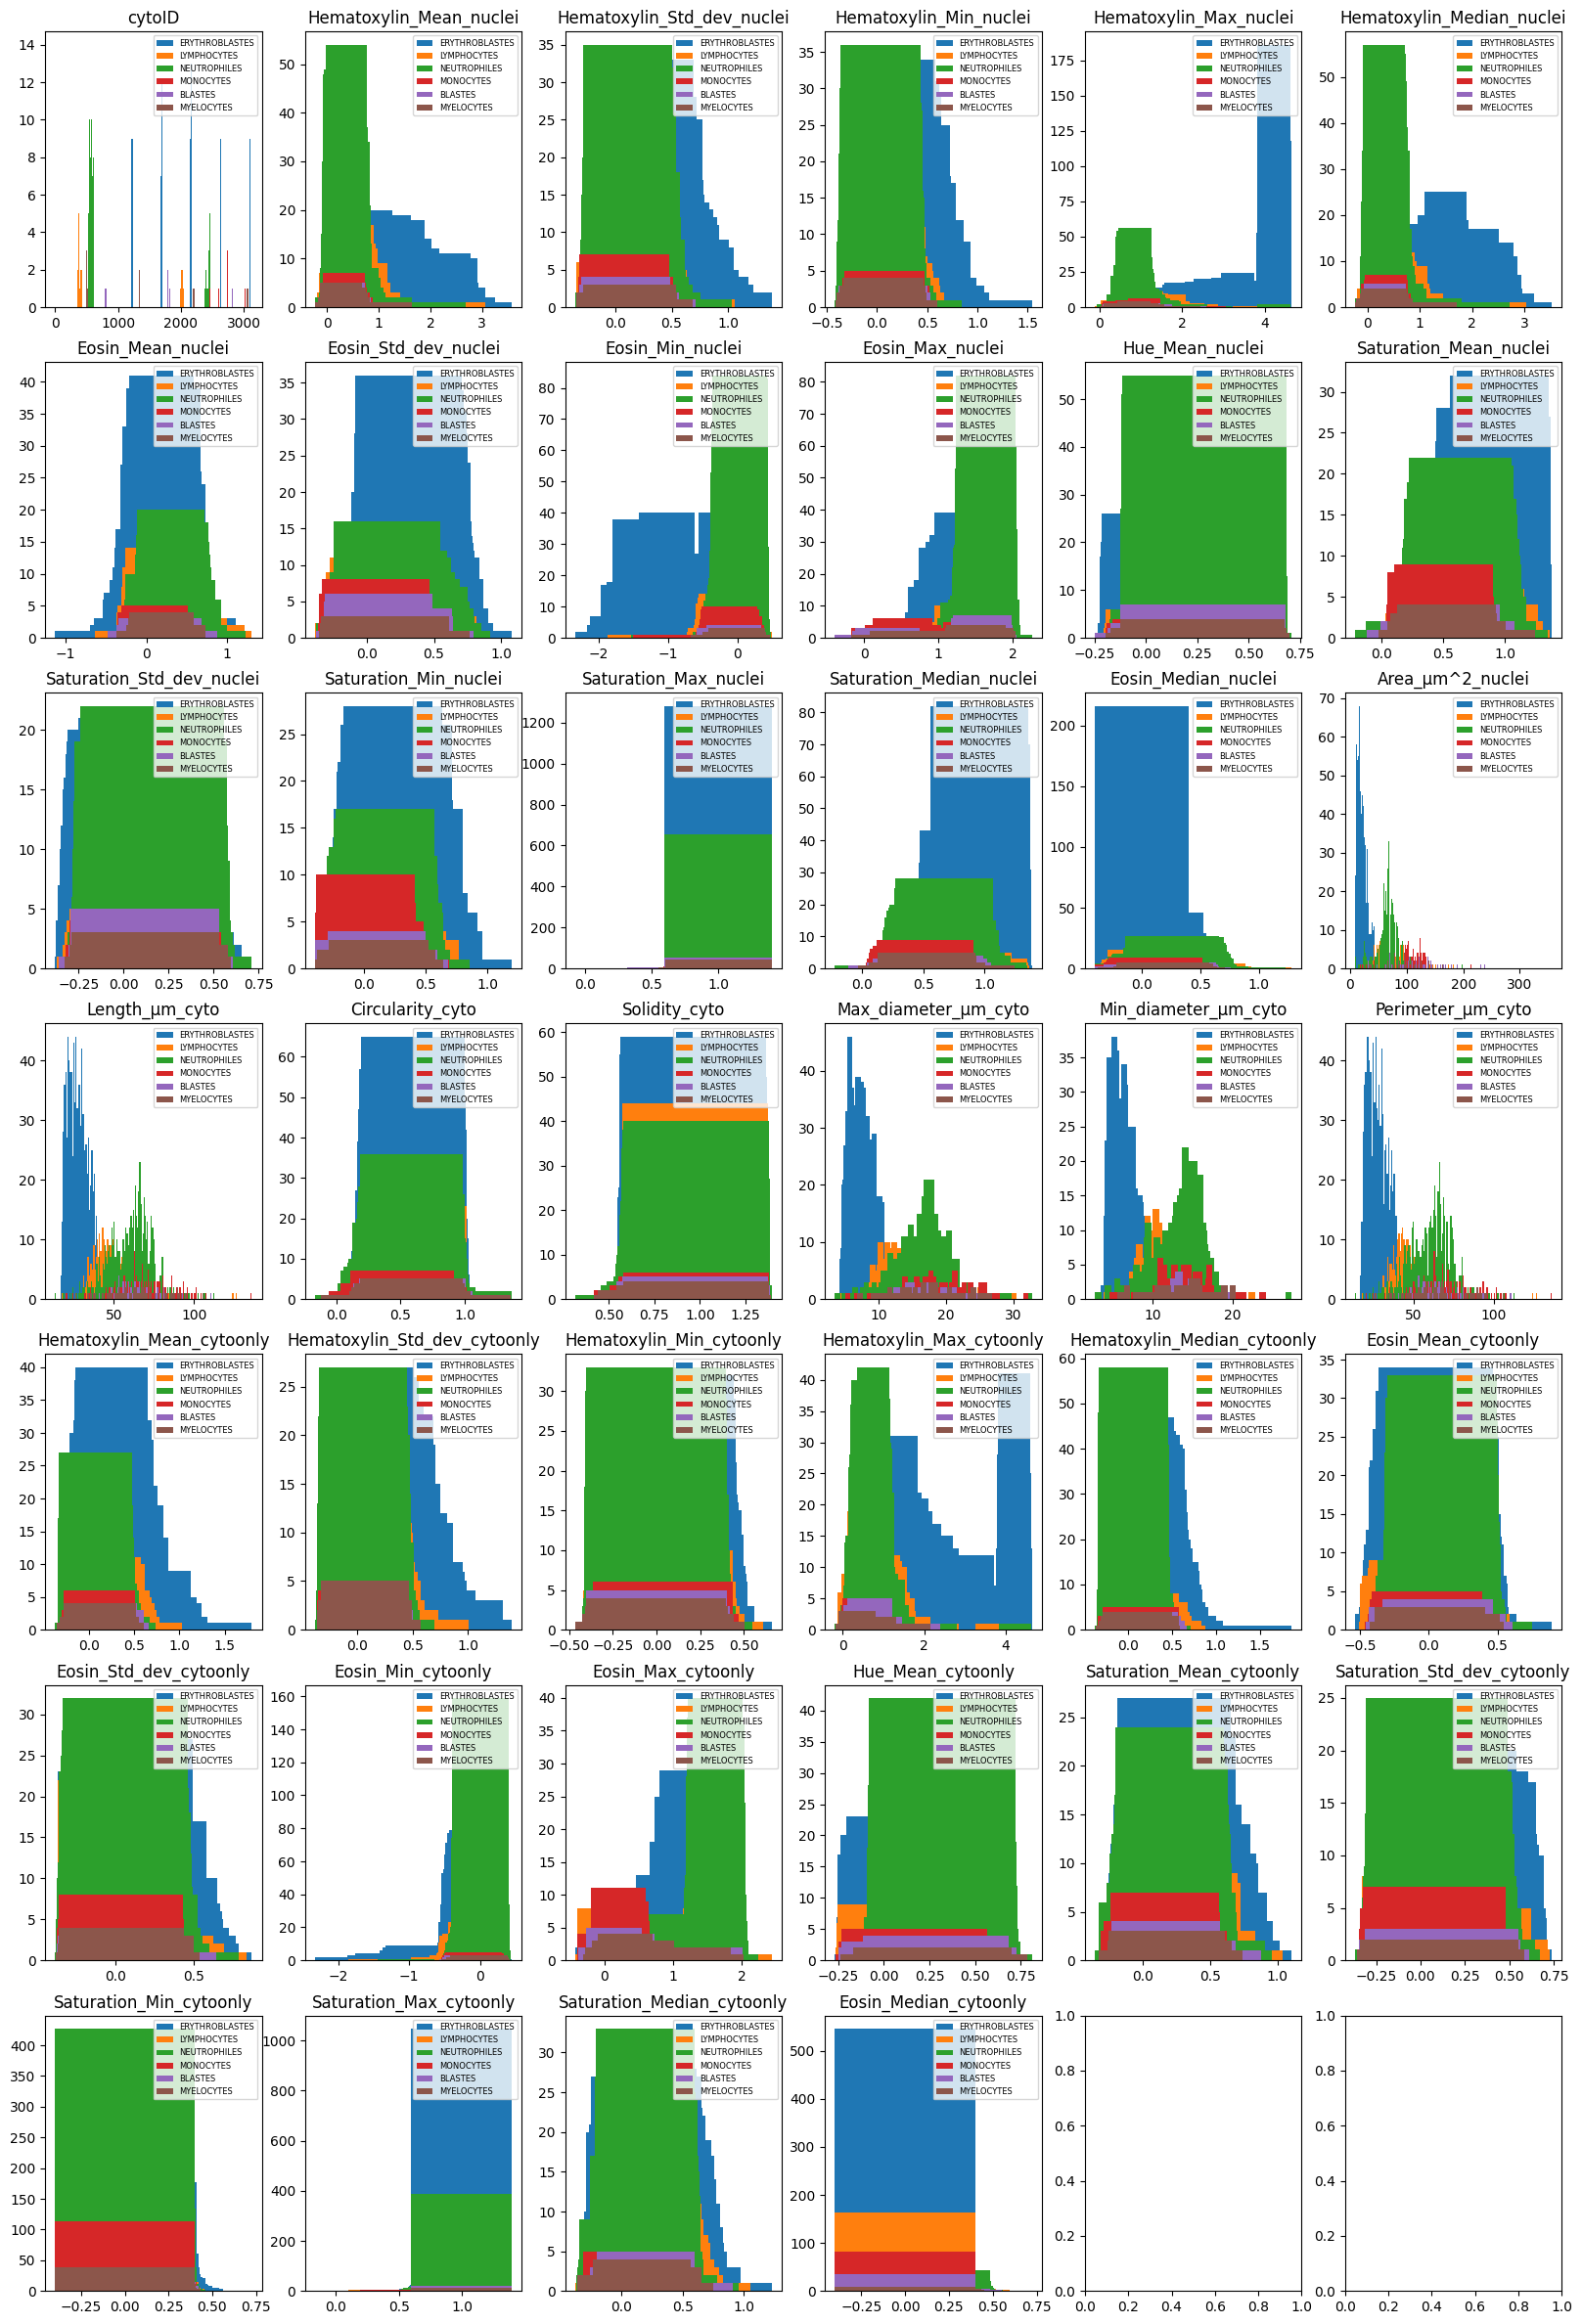

6) The above figure represents the distribution of cells according to features.

Which features do you think are the most discriminative for determining cell class? Explain.

**Answer**:
Les features les plus discriminantes semblent être principalement Area_µm²_nuclei, Max_diameter_µm_cyto, Circularity_cyto et Hematoxylin_Max_nuclei. Les histogrammes montrent des différences nettes entre classes pour ces variables. Les mesures géométriques (aire, diamètre, circularité) capturent les variations de taille et de forme entre les types cellulaires, tandis que l’intensité de coloration nucléaire reflète les différences de structure du noyau selon le stade de maturation. Ces caractéristiques sont donc à la fois statistiquement discriminantes et biologiquement cohérentes.

7) a) Using scatter_matrix(), represent the correlation between 6 geometrical features.

b) Do the same for 6 colour features (preferably different colour features, ex: Eosin, Hematoxylin, Hue...)

*Expected result*

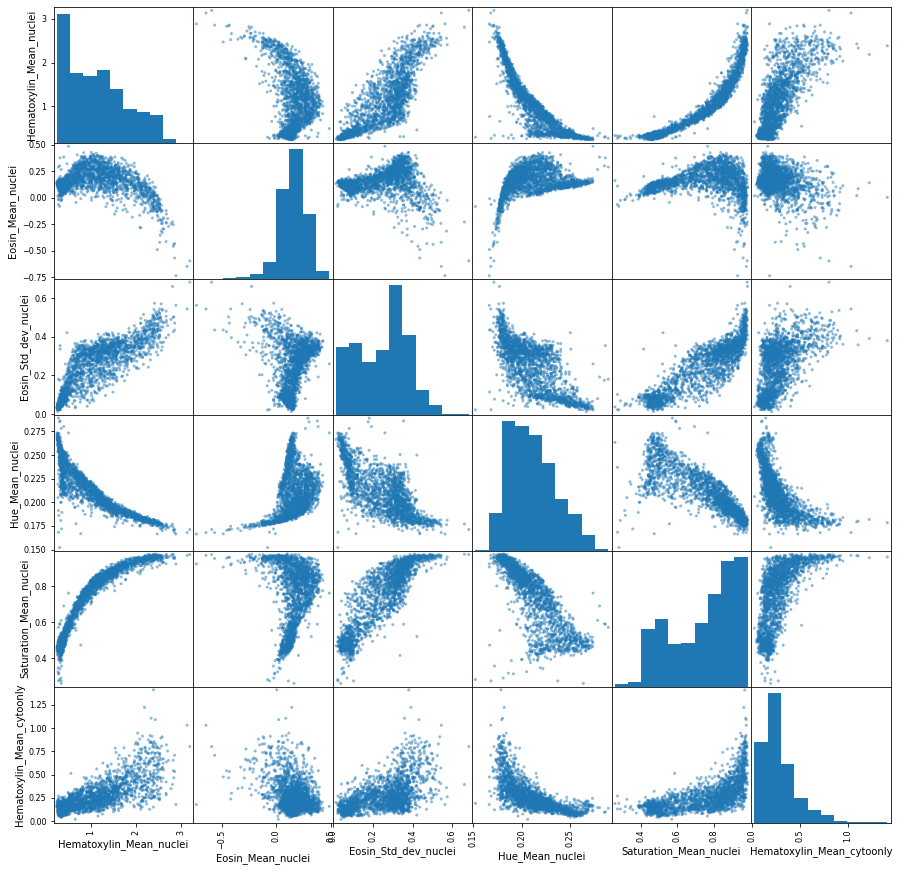


<Figure size 1000x1000 with 0 Axes>

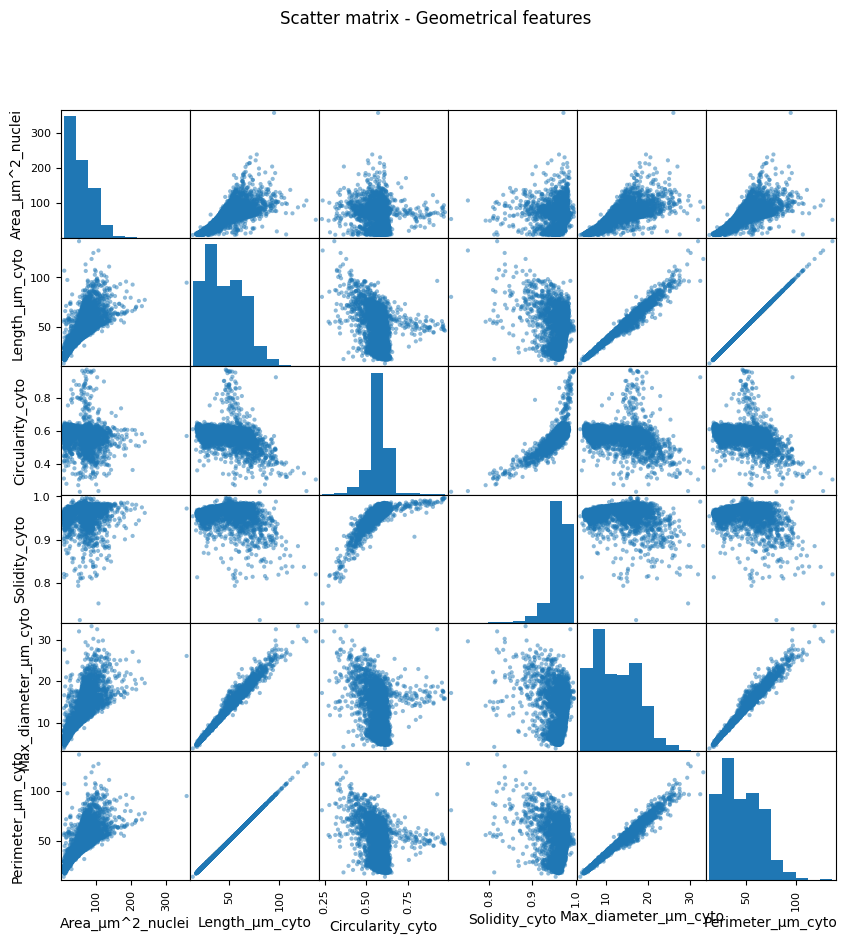

<Figure size 1000x1000 with 0 Axes>

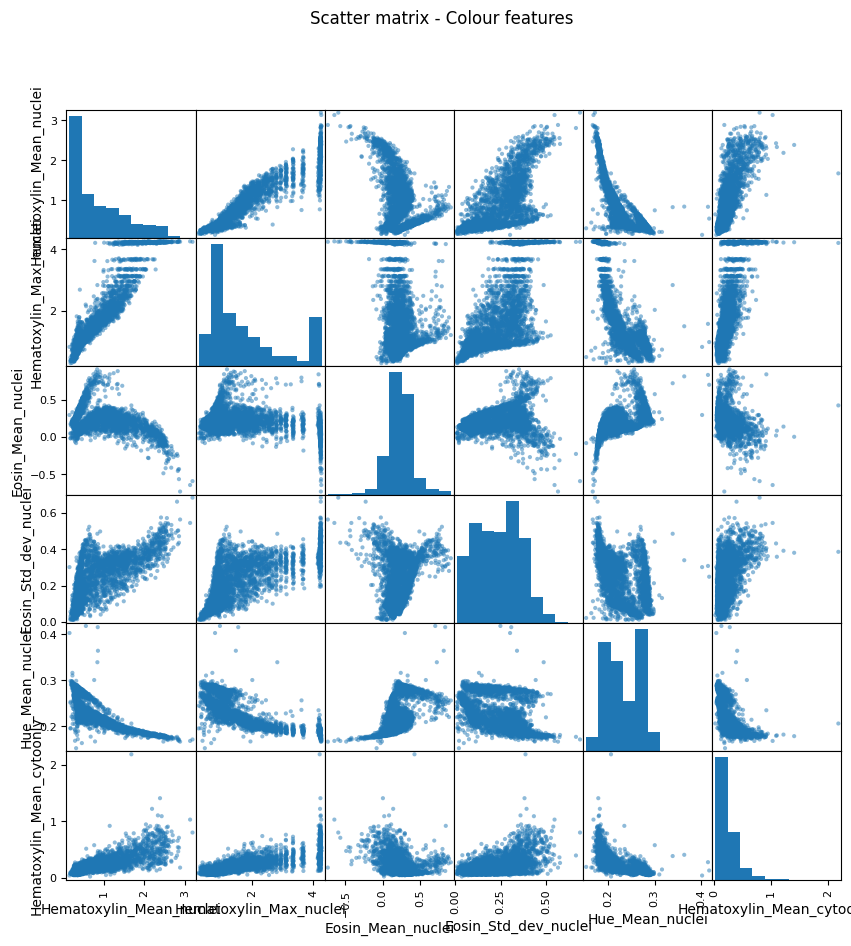

In [146]:
#Answer 
geo_feat = [
    'Area_µm^2_nuclei',
    'Length_µm_cyto',
    'Circularity_cyto',
    'Solidity_cyto',
    'Max_diameter_µm_cyto',
    'Perimeter_µm_cyto'
]

geo_dataset = dataset[geo_feat]

plt.figure(figsize=(10,10))
scatter_matrix(
    geo_dataset,
    figsize=(10,10),
    alpha=0.5,
    diagonal='hist'
)
plt.suptitle("Scatter matrix - Geometrical features")
plt.show()


color_feat = [
    'Hematoxylin_Mean_nuclei',
    'Hematoxylin_Max_nuclei',
    'Eosin_Mean_nuclei',
    'Eosin_Std_dev_nuclei',
    'Hue_Mean_nuclei',
    'Hematoxylin_Mean_cytoonly'
]

color_dataset = dataset[color_feat]

plt.figure(figsize=(10,10))
scatter_matrix(
    color_dataset,
    figsize=(10,10),
    alpha=0.5,
    diagonal='hist'
)
plt.suptitle("Scatter matrix - Colour features")
plt.show()






8) Represent the repartition of cells by class for two of the most discriminative features, using sns.boxplot.


*Expected result for a random selected feature*

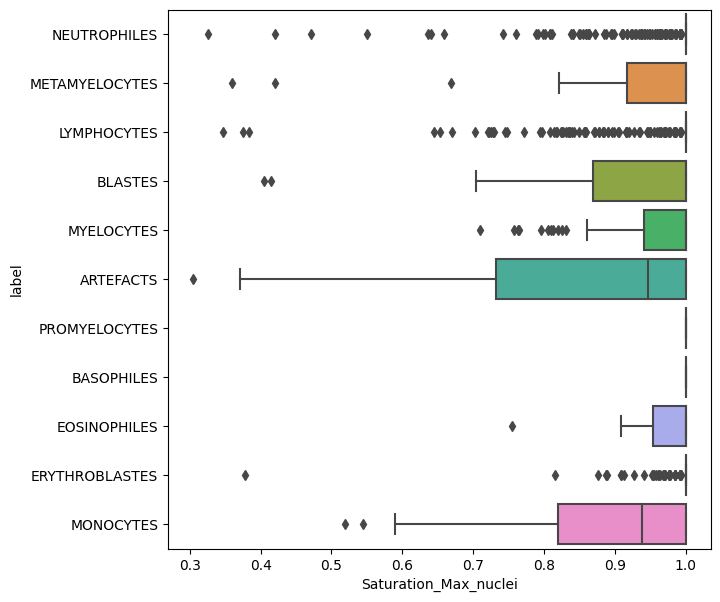

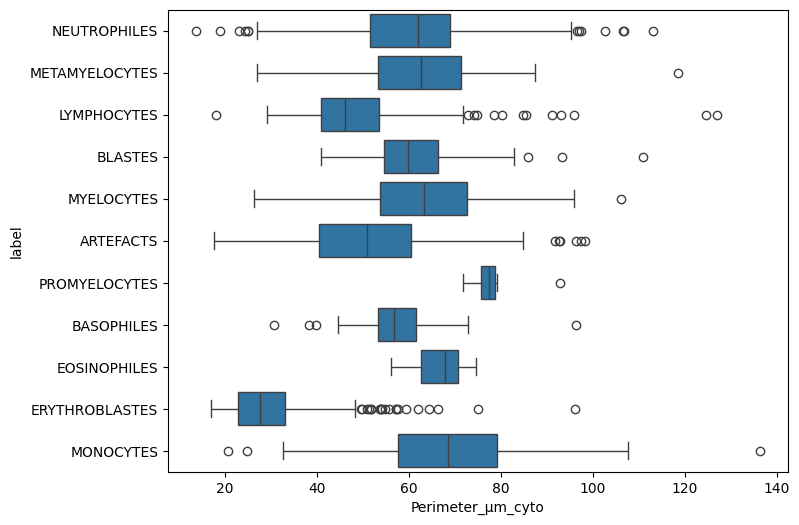

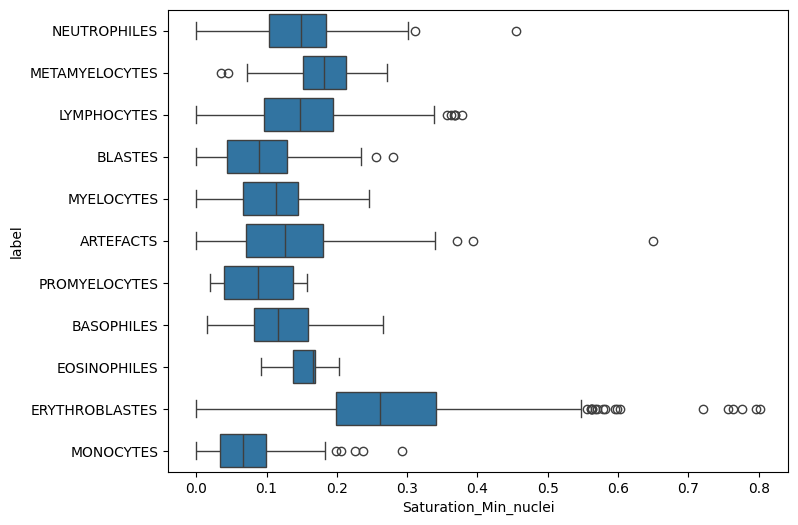

In [137]:
#Answer
plt.figure(figsize=(8,6))

sns.boxplot(x='Perimeter_µm_cyto',y='label',data=dataset)
plt.xlabel("Perimeter_µm_cyto")
plt.ylabel("label")
plt.show()


plt.figure(figsize=(8,6))

sns.boxplot(x='Saturation_Min_nuclei',y='label',data=dataset)
plt.xlabel("Saturation_Min_nuclei")
plt.ylabel("label")
plt.show()


# Create X and y



In [138]:
X = dataset.drop(['cytoID', 'label'], axis=1)
len(X)
y = dataset[['label']]
y

,label
0,NEUTROPHILES
1,METAMYELOCYTES
2,NEUTROPHILES
3,LYMPHOCYTES
4,NEUTROPHILES
...,...
3105,ERYTHROBLASTES
3106,ERYTHROBLASTES
3107,ERYTHROBLASTES
3108,ERYTHROBLASTES


# Splitting the dataset

*train_test_split* allows us to make the split, and makes sure the class distribution is the same in the train and the test as the initial distribution.

We decide to keep 20% of the data for the test with *test_size*.

*random_state* allows us to have the same random cut everytime we run the code, and thus to make the results repeatable.


In [139]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size= 0.2, random_state=42)

Remark: train_test_split keeps the distribution of classes
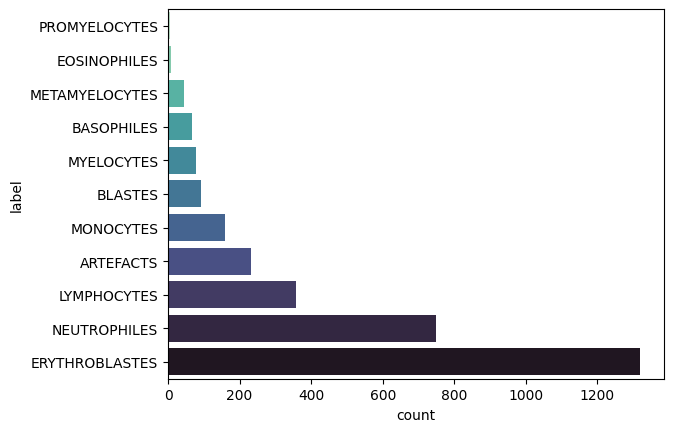


# Rescale data

9) Use *SandardScaler()* to rescale data in X_train.

Remark: the standardscaler is trained on X_train using *fit_transform*, and then applied on X_test using *transform*.

In [140]:
#Answer 
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Training model

## SVM model

10) Train a SVM model on the training dataset. Use it to make prediction of the test dataset.


11) Evaluate your performance using *confusion_matrix* and *classification_report*.

You can use *plot_confusion* to visualise the normalised confusion matrix.

*Expected result*


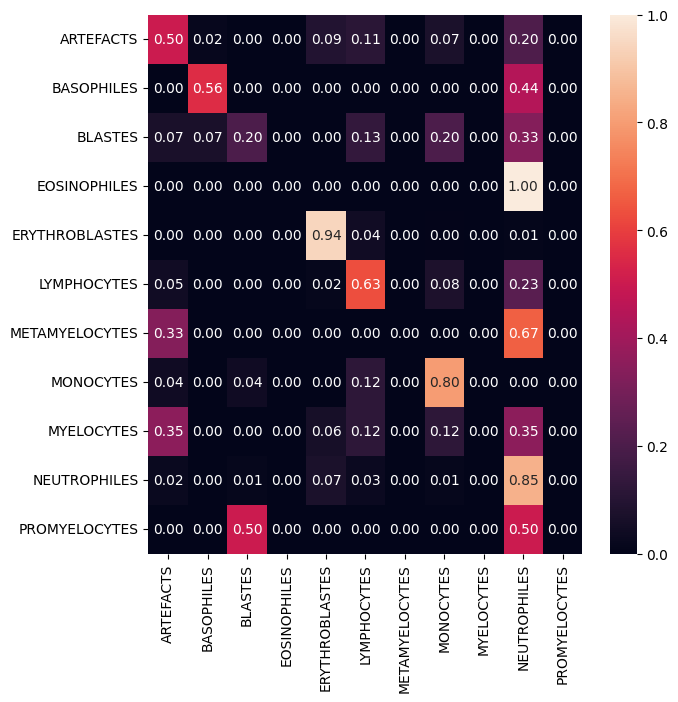

/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


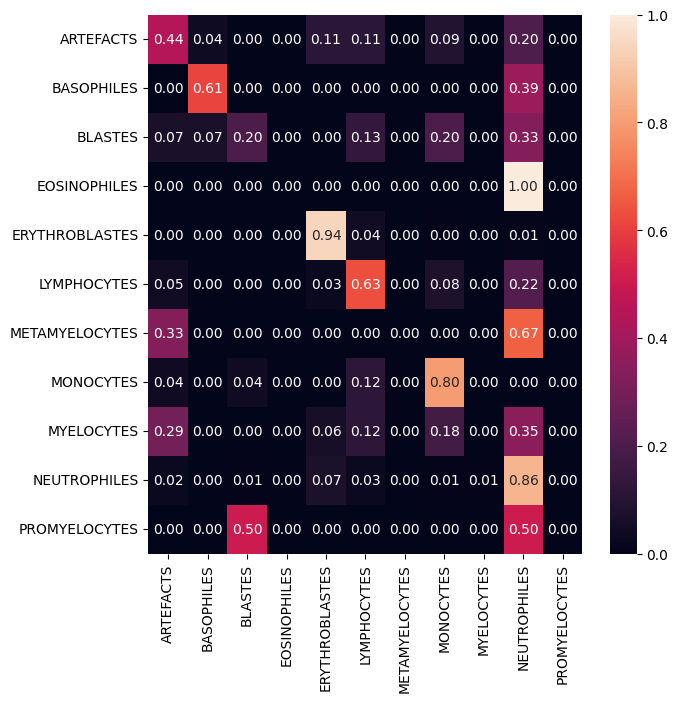

/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

In [141]:
#Answer 
SVM_model=svm.SVC()
SVM_model.fit(X_train_scaled,y_train)

y_pred_svm=SVM_model.predict(X_test_scaled)

plot_confusion(y_pred_svm,y_test)

results = []


accuracy=accuracy_score(y_test, y_pred_svm)
report = classification_report(y_test, y_pred_svm, output_dict=True)
precision = report['macro avg']['precision']
recall = report['macro avg']['recall']
f1 = report['macro avg']['f1-score']

results.append({
    "Model": "SVM_with_PCA",
    "Accuracy": accuracy,
    "Precision_macro": precision,
    "Recall_macro": recall,
    "F1_macro": f1
})



## Random Forest
13 )  Repeat 10) and 11) but with RandomForest model

/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


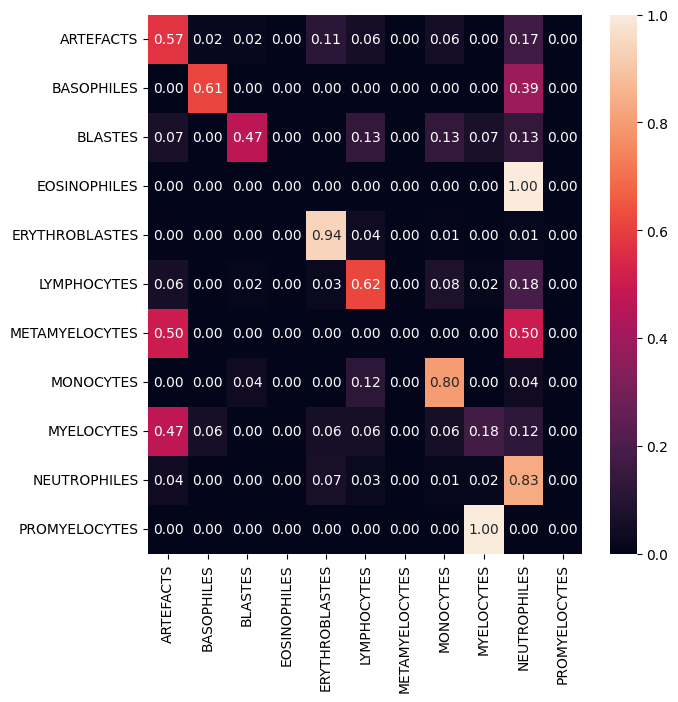

/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

In [142]:
#Answer 
RF_model=RandomForestClassifier()
RF_model.fit(X_train_scaled,y_train)

y_pred_rf=RF_model.predict(X_test_scaled)

plot_confusion(y_pred_rf,y_test)

accuracy=accuracy_score(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf, output_dict=True)
precision = report['macro avg']['precision']
recall = report['macro avg']['recall']
f1 = report['macro avg']['f1-score']

results.append({
    "Model": "SVM_with_PCA",
    "Accuracy": accuracy,
    "Precision_macro": precision,
    "Recall_macro": recall,
    "F1_macro": f1
})



# Dimensionality reduction

14) The number of features is important compared with the number of cells. Use dimensionality reduction technique such as PCA to keep only 8 principal components, and evaluate the performance of SVM and RandomForest using only these 8 features. Do you know other dimensionality reduction method and how they work?

/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


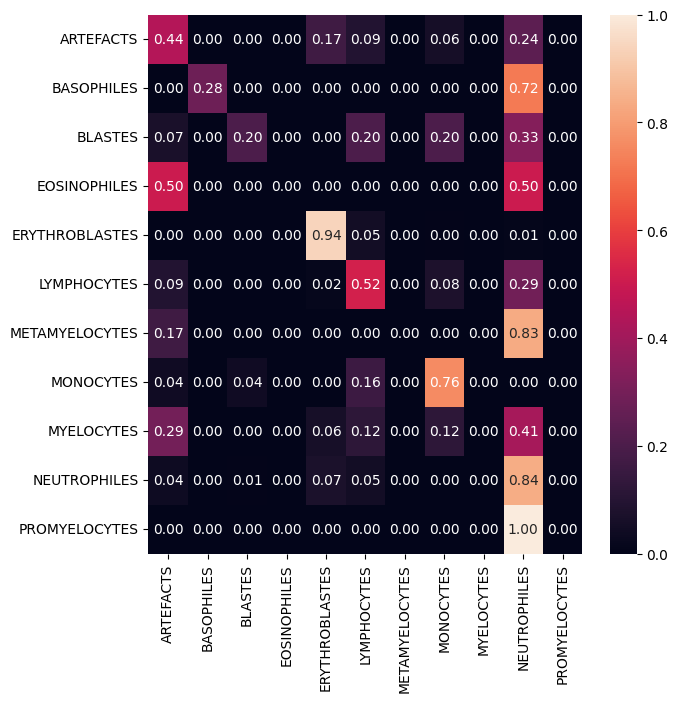

/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

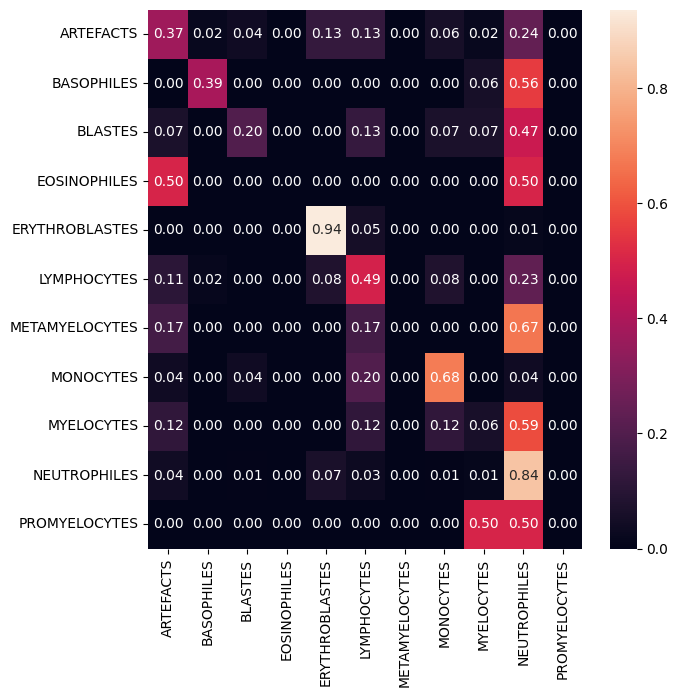

/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/r1/Desktop/semestre2/Medical ML/TP3_medical/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

In [143]:
#Answer
pca=PCA(n_components=8)
X_train_reduced=pca.fit_transform(X_train_scaled)
X_test_reduced=pca.transform(X_test_scaled)

SVM_model_pca=svm.SVC()
SVM_model_pca.fit(X_train_reduced,y_train)
y_pred_svm_pca=SVM_model_pca.predict(X_test_reduced)
plot_confusion(y_pred_svm_pca,y_test)
accuracy = accuracy_score(y_test, y_pred_svm_pca)
report = classification_report(y_test, y_pred_svm_pca, output_dict=True)

precision = report['macro avg']['precision']
recall = report['macro avg']['recall']
f1 = report['macro avg']['f1-score']

results.append({
    "Model": "SVM_with_PCA",
    "Accuracy": accuracy,
    "Precision_macro": precision,
    "Recall_macro": recall,
    "F1_macro": f1
})


RF_model_pca=RandomForestClassifier()
RF_model_pca.fit(X_train_reduced,y_train)
y_pred_rf_pca=RF_model_pca.predict(X_test_reduced)
plot_confusion(y_pred_rf_pca,y_test)
accuracy=accuracy_score(y_test, y_pred_rf_pca)
report = classification_report(y_test, y_pred_rf_pca, output_dict=True)
precision = report['macro avg']['precision']
recall = report['macro avg']['recall']
f1 = report['macro avg']['f1-score']

results.append({
    "Model": "SVM_with_PCA",
    "Accuracy": accuracy,
    "Precision_macro": precision,
    "Recall_macro": recall,
    "F1_macro": f1
})



**Answer :**
En plus de la PCA, il existe d’autres techniques de réduction de dimension :
	•	LDA (Linear Discriminant Analysis) :
Contrairement à la PCA, la LDA est une méthode supervisée qui vise à maximiser la séparabilité entre les classes en projetant les données dans un espace qui maximise le rapport entre la variance inter-classe et la variance intra-classe.
	•	t-SNE :
Méthode non linéaire principalement utilisée pour la visualisation. Elle préserve la structure locale des données en modélisant les similarités par paires entre les points.
	•	UMAP :
Autre technique non linéaire qui préserve à la fois la structure locale et globale des données, souvent mieux que t-SNE, tout en étant plus rapide en termes de calcul.


# Interpretation of the results

15) Are the results satisfying? Looking at the confusion matrix, what problem(s) are we encountering here?

16) Are there ways to reduce these problems?

In [144]:
#Answer
results_df = pd.DataFrame(results)
display(results_df)


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,SVM_with_PCA,0.770096,0.422793,0.407952,0.404396
1,SVM_with_PCA,0.782958,0.482835,0.456095,0.462305
2,SVM_with_PCA,0.741158,0.436166,0.362235,0.369207
3,SVM_with_PCA,0.731511,0.409818,0.360516,0.371971


**Answer :**
Les résultats sont globalement corrects mais restent limités. Les matrices de confusion montrent que certaines classes comme les érythroblastes et les neutrophiles sont bien reconnues, tandis que d’autres, notamment les promyélocytes, métamyélocytes ou basophiles, sont fréquemment confondues avec des classes biologiquement proches. On observe notamment une forte confusion entre les différents stades de maturation, ce qui est cohérent avec leur similarité morphologique.

Le tableau des métriques confirme cette analyse : bien que l’accuracy soit relativement correcte (autour de 0.75–0.78), les scores macro (precision, recall, F1) sont nettement plus faibles. Cet écart indique que les performances sont bonnes sur les classes majoritaires mais beaucoup plus faibles sur les classes minoritaires. Le déséquilibre important du dataset joue donc un rôle majeur, car les classes dominantes influencent fortement l’apprentissage et masquent les difficultés sur les classes rares.


Pour réduire ces problèmes, il serait possible d’utiliser des techniques de gestion du déséquilibre comme le paramètre class_weight='balanced', du suréchantillonnage (SMOTE) ou du sous-échantillonnage. On pourrait également tester une réduction de dimension supervisée comme la LDA, ou affiner les hyperparamètres des modèles afin d’améliorer la séparation entre classes proches.

# Medical interpretation

17) What are the important features for prediction? How could we interpret results of the model?

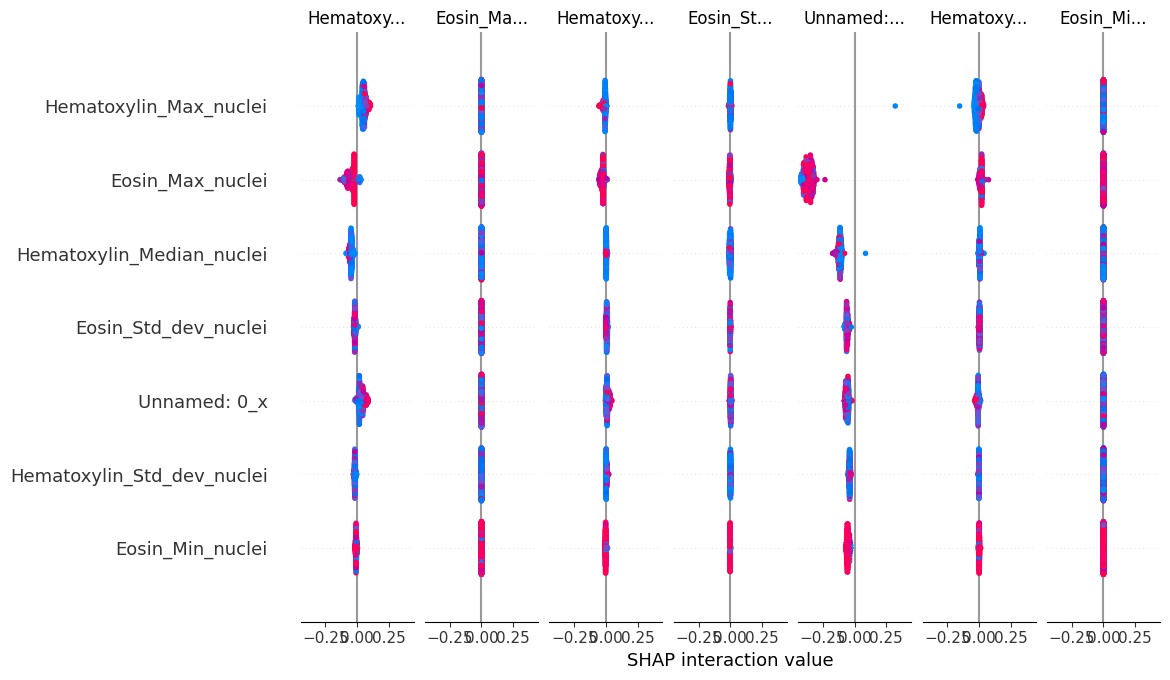

In [147]:
#Answer
import shap

explainer = shap.TreeExplainer(RF_model_pca)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)


**Answer :**
L’analyse SHAP montre que les variables les plus importantes pour la prédiction sont principalement liées à la coloration nucléaire, notamment Hematoxylin_Max_nuclei, Eosin_Max_nuclei et les mesures de médiane ou d’écart-type de ces intensités. Cela indique que la densité et la variabilité de la coloration du noyau jouent un rôle majeur dans la classification des cellules.

D’un point de vue médical, ces résultats sont cohérents : la maturation cellulaire s’accompagne de modifications de la structure nucléaire et de la chromatine, ce qui influence directement l’intensité de la coloration. Le modèle semble donc exploiter des caractéristiques biologiquement pertinentes pour différencier les classes. Cependant, la similarité entre certains stades de maturation explique les confusions observées dans les matrices.